# Room 361 Pseudo-Labeling

This notebook turns manual headcount anchors into uncertainty-bounded occupancy pseudo-labels for Room 361.

It is a weak-supervision workflow, not a classical bootstrap:
- direct counts anchor the midpoint
- door-closed windows get higher confidence
- label ranges widen slightly when the nearby sensor behavior is less stable


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from scripts.occupancy_pseudo_labels import (
    generate_pseudo_labels,
    load_room_fpb_timeseries,
    summarize_pseudo_labels,
)
from scripts.occupancy_residual_model import (
    fit_residual_correction_model,
    residual_model_coefficients,
)

INPUT_FILES = [Path("data/4_3To4_9.csv")]
ANCHOR_FILE = Path("data/room361_manual_anchors.csv")
OUTPUT_FILE = Path("reports/room361_4_3_to_4_9_pseudo_labels.csv")
TIME_COL = "dateTime"
RESAMPLE_RULE = "5min"
OCCUPANCY_MIN = 0
OCCUPANCY_MAX = 45


In [2]:
anchors = pd.read_csv(ANCHOR_FILE)
sensor = load_room_fpb_timeseries(
    INPUT_FILES,
    time_col=TIME_COL,
    resample_rule=RESAMPLE_RULE,
    min_occupancy=OCCUPANCY_MIN,
    max_occupancy=OCCUPANCY_MAX,
)
labeled, label_rows, normalized_anchors = generate_pseudo_labels(
    sensor,
    anchors,
    min_occupancy=OCCUPANCY_MIN,
    max_occupancy=OCCUPANCY_MAX,
)
summary = summarize_pseudo_labels(labeled, normalized_anchors)
labeled, residual_training, residual_model, residual_features = fit_residual_correction_model(
    labeled,
    min_occupancy=OCCUPANCY_MIN,
    max_occupancy=OCCUPANCY_MAX,
)
coef_df = residual_model_coefficients(residual_model, residual_features)

display(pd.Series(summary, name="value"))
display(
    normalized_anchors[
        [
            "anchor_id",
            "anchor_time",
            "count",
            "occ_low",
            "occ_high",
            "confidence",
            "reason",
        ]
    ]
)

preview_cols = [
    "co2_ppm",
    "flow_cfm",
    "occ_physics_est_smooth",
    "occ_formula_residual",
    "occ_hybrid_pred",
    "occ_low",
    "occ_high",
    "occ_mid",
    "confidence",
    "label_source",
    "sensor_stable_for_label",
]
display(labeled.loc[labeled["has_pseudo_label"], preview_cols])
display(residual_training[["occ_mid", "occ_physics_est_smooth", "occ_formula_residual", "occ_hybrid_fitted", "occ_hybrid_fitted_abs_error", "confidence_weight"]])
display(coef_df)

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
labeled.reset_index().to_csv(OUTPUT_FILE, index=False)
label_rows.to_csv(OUTPUT_FILE.with_name(f"{OUTPUT_FILE.stem}_label_rows.csv"), index=False)
normalized_anchors.to_csv(OUTPUT_FILE.with_name(f"{OUTPUT_FILE.stem}_anchors_normalized.csv"), index=False)
residual_training.to_csv(OUTPUT_FILE.with_name(f"{OUTPUT_FILE.stem}_residual_training.csv"), index=False)
coef_df.to_csv(OUTPUT_FILE.with_name(f"{OUTPUT_FILE.stem}_residual_coefficients.csv"), index=False)

print(f"Saved labeled rows to {OUTPUT_FILE.resolve()}")


sensor_rows                                     1872
label_rows                                        14
label_coverage_pct                              0.75
anchor_rows                                        3
overlapping_anchor_rows                            3
sensor_start                     2026-04-03T00:00:00
sensor_end                       2026-04-09T11:55:00
confidence_counts          {'high': 12, 'medium': 2}
label_source_counts                   {'anchor': 14}
Name: value, dtype: object

,anchor_id,anchor_time,count,occ_low,occ_high,confidence,reason
0,A1,2026-04-07 14:38:00,33,30,36,medium,direct count only
1,A2,2026-04-08 15:00:00,11,9,13,high,direct count with no doors open for 20 minutes
2,A3,2026-04-08 15:30:00,13,11,15,high,direct count with no doors open for 30 minutes


,co2_ppm,flow_cfm,occ_physics_est_smooth,occ_formula_residual,occ_hybrid_pred,occ_low,occ_high,occ_mid,confidence,label_source,sensor_stable_for_label
ts,,,,,,,,,,,
2026-04-07 14:35:00,556.000000,1132.681193,9.739410,23.260590,30.964270,27.0,39.0,33.0,medium,anchor,False
2026-04-07 14:40:00,528.750000,1128.706390,11.385828,21.614172,27.579145,27.0,39.0,33.0,medium,anchor,False
2026-04-08 14:50:00,519.100000,1130.829366,12.088443,-1.088443,10.229466,8.0,14.0,11.0,high,anchor,True
2026-04-08 14:55:00,526.125000,1123.992773,11.772849,-0.772849,10.388991,8.0,14.0,11.0,high,anchor,True
2026-04-08 15:00:00,510.714286,1125.108189,11.021912,-0.021912,14.697619,9.0,13.0,11.0,high,anchor,True
2026-04-08 15:05:00,529.500000,1118.776896,11.348519,-0.348519,11.838504,8.0,14.0,11.0,high,anchor,True
2026-04-08 15:10:00,521.571429,1131.954102,11.214180,-0.214180,10.506532,8.0,14.0,11.0,high,anchor,True
2026-04-08 15:15:00,553.777778,1130.458405,12.761964,0.238036,12.498978,9.0,17.0,13.0,high,anchor,False
2026-04-08 15:20:00,529.857143,1111.395752,12.747861,0.252139,10.444724,10.0,16.0,13.0,high,anchor,True


,occ_mid,occ_physics_est_smooth,occ_formula_residual,occ_hybrid_fitted,occ_hybrid_fitted_abs_error,confidence_weight
ts,,,,,,
2026-04-07 14:35:00,33.0,9.739410,23.260590,30.964270,2.035730,0.65
2026-04-07 14:40:00,33.0,11.385828,21.614172,27.579145,5.420855,0.65
2026-04-08 14:50:00,11.0,12.088443,-1.088443,10.229466,0.770534,1.00
2026-04-08 14:55:00,11.0,11.772849,-0.772849,10.388991,0.611009,1.00
2026-04-08 15:00:00,11.0,11.021912,-0.021912,14.697619,3.697619,1.00
2026-04-08 15:05:00,11.0,11.348519,-0.348519,11.838504,0.838504,1.00
2026-04-08 15:10:00,11.0,11.214180,-0.214180,10.506532,0.493468,1.00
2026-04-08 15:15:00,13.0,12.761964,0.238036,12.498978,0.501022,1.00
2026-04-08 15:20:00,13.0,12.747861,0.252139,10.444724,2.555276,1.00


,feature,coefficient
0,co2_ppm,4.260787
1,occ_physics_est_smooth,-3.812582
2,humidity_pct,-3.555532
3,flow_pct_change,-1.314475
4,humidity_delta_pct,-0.990362
5,co2_slope_ppm,-0.787642
6,temp_f,0.713060
7,flow_cfm,0.151917


Saved labeled rows to /workspaces/CSC_4260_project/reports/room361_4_3_to_4_9_pseudo_labels.csv


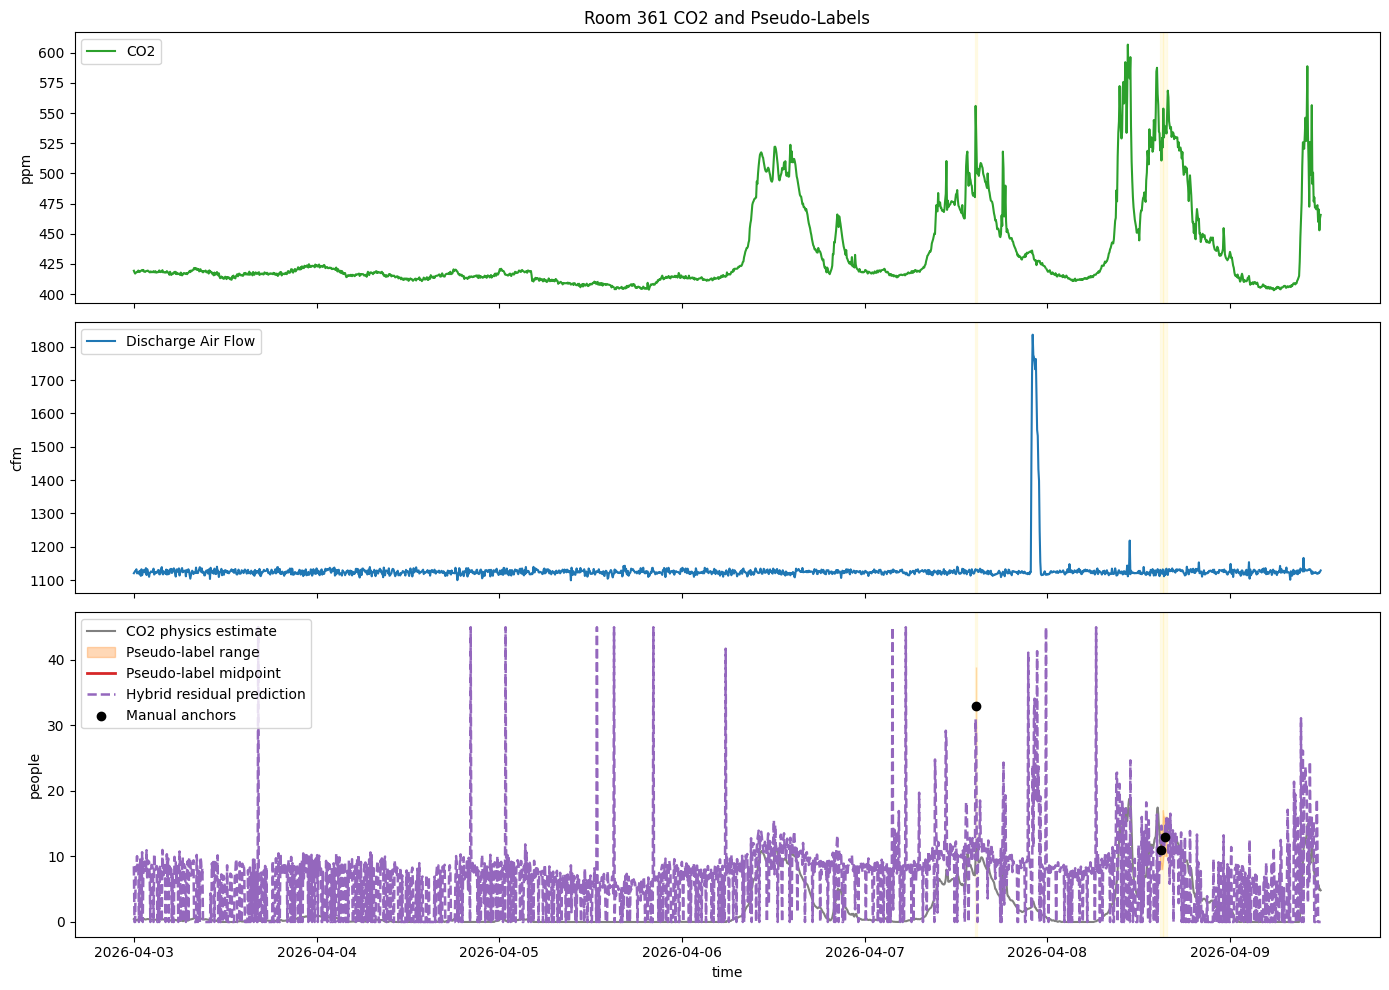

In [3]:
plot_df = labeled.reset_index()

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1.2]},
)

axes[0].plot(plot_df["ts"], plot_df["co2_ppm"], color="tab:green", label="CO2")
axes[0].set_ylabel("ppm")
axes[0].set_title("Room 361 CO2 and Pseudo-Labels")
axes[0].legend(loc="upper left")

axes[1].plot(plot_df["ts"], plot_df["flow_cfm"], color="tab:blue", label="Discharge Air Flow")
axes[1].set_ylabel("cfm")
axes[1].legend(loc="upper left")

mask = plot_df["has_pseudo_label"].fillna(False)
axes[2].plot(
    plot_df["ts"],
    plot_df["occ_physics_est_smooth"],
    color="0.5",
    linewidth=1.5,
    label="CO2 physics estimate",
)
axes[2].fill_between(
    plot_df["ts"],
    plot_df["occ_low"],
    plot_df["occ_high"],
    where=mask,
    color="tab:orange",
    alpha=0.30,
    label="Pseudo-label range",
)
axes[2].plot(
    plot_df["ts"],
    plot_df["occ_mid"],
    color="tab:red",
    linewidth=2,
    label="Pseudo-label midpoint",
)
axes[2].plot(
    plot_df["ts"],
    plot_df["occ_hybrid_pred"],
    color="tab:purple",
    linestyle="--",
    linewidth=1.8,
    label="Hybrid residual prediction",
)
axes[2].scatter(
    normalized_anchors["anchor_time"],
    normalized_anchors["count"],
    color="black",
    zorder=4,
    label="Manual anchors",
)
axes[2].set_ylabel("people")
axes[2].set_xlabel("time")
axes[2].legend(loc="upper left")

for axis in axes:
    for anchor in normalized_anchors.itertuples(index=False):
        axis.axvspan(anchor.window_start, anchor.window_end, color="gold", alpha=0.08)

plt.tight_layout()
plt.show()


In [4]:
window_cols = [
    "co2_ppm",
    "co2_slope_ppm",
    "flow_cfm",
    "humidity_pct",
    "sensor_stable",
    "occ_low",
    "occ_high",
    "occ_mid",
    "occ_formula_residual",
    "occ_hybrid_pred",
    "confidence",
    "label_reason",
]
labeled.loc["2026-04-07 14:25":"2026-04-08 15:45", window_cols]


,co2_ppm,co2_slope_ppm,flow_cfm,humidity_pct,sensor_stable,occ_low,occ_high,occ_mid,occ_formula_residual,occ_hybrid_pred,confidence,label_reason
ts,,,,,,,,,,,,
2026-04-07 14:25:00,482.857143,-0.642857,1120.911743,NaN,True,NaN,NaN,NaN,NaN,10.936367,NaN,NaN
2026-04-07 14:30:00,480.333333,-2.523810,1129.285610,NaN,True,NaN,NaN,NaN,NaN,9.599608,NaN,NaN
2026-04-07 14:35:00,556.000000,75.666667,1132.681193,31.400000,False,27.0,39.0,33.0,23.260590,30.964270,medium,direct count only
2026-04-07 14:40:00,528.750000,-27.250000,1128.706390,30.000000,False,27.0,39.0,33.0,21.614172,27.579145,medium,direct count only
2026-04-07 14:45:00,505.600000,-23.150000,1129.803955,NaN,True,NaN,NaN,NaN,NaN,7.251557,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-08 15:25:00,539.444444,9.587302,1120.702454,32.700001,True,10.0,16.0,13.0,-0.340351,13.172899,high,direct count with no doors open for 30 minutes
2026-04-08 15:30:00,536.857143,-2.587302,1114.998698,32.750000,True,11.0,15.0,13.0,0.320751,14.721431,high,direct count with no doors open for 30 minutes
2026-04-08 15:35:00,536.571429,-0.285714,1132.472473,32.500000,True,10.0,16.0,13.0,0.005347,12.347476,high,direct count with no doors open for 30 minutes
